In [1]:
# “In go.Pie(), labels represent actual category values, while in px.pie(), labels are only used for renaming and names represent the categories.”


# | Parameter | `px.pie()`   | `go.Pie()`          |
# | --------- | ------------ | ------------------- |
# | `names`   | ✅ categories | ❌ not used          |
# | `name`    | ❌ not used   | ✅ trace/legend name |


In [2]:
# “Quantitative data is numerical and used for calculations, while qualitative data represents categories used for classification.”

# Quantity = Quantitative = Numbers
# Quality = Qualitative = Type/Category

In [3]:
# “After groupby aggregation, we use reset_index(name='column_name') to convert the result into a DataFrame and assign a meaningful column name.”

In [4]:
# if  some  ask , which  is  use  in which  switchation  ?

# "It depends on what question the data is answering."

# I use a bar chart when I want to compare values across categories — like which product sold the most, or how revenue differs across shipping carriers. 
# I use a pie or donut chart when I want to show how a whole is divided into parts — like when 45% of business comes from skincare, 29.5% from haircare, and 25.5% from cosmetics. The viewer needs to feel the proportion, not the exact number. The values already add up to 100%, so pie chart is the natural fit.
# The one-line rule I follow: if the question has the word 'how much' or 'which is more' — bar chart. 
# If the question has the word 'what share' or 'what percentage' — pie chart.

# "Bar = comparison. Pie = composition. When in doubt — bar chart."

In [5]:
# Raw data → messy → order = first appearance
# Groupby data → clean → order = structured

In [6]:
# Chart type	Use
# Bar / Scatter	x, y
# Pie / Donut	names, values

In [7]:
import  numpy as  np  
import  pandas  as  pd  
df= pd.read_csv('C:\\Users\\Admin\\pandas\\supply_chain - supply_chain.csv')
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [8]:
import plotly.express as px 
import plotly.io as  pio 
import  plotly.graph_objects as go 
pio.templates.default = "plotly_white"

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

# now  let`s started with analyzing the  supply chain  by looking at  the  relationship between  the price of the  product and  the  revenue generated by them:

In [10]:
fig  =  px.scatter(df
                   ,x="Price"
                   ,y="Revenue generated"
                   ,color = "Product type"
                   ,hover_data = ['Number of products sold'],
                   trendline="ols")
fig.show()

# thus ,  the  company drives more revenue from skincare  product , and  the  higher  the  price  of skincare  product ,  the  more  revenue they  generate . Now  let's have  look  at the sales  by product type:

In [11]:
sales_data = df.groupby('Product type')['Number of products sold'].sum().reset_index()
sales_data 

,Product type,Number of products sold
0,cosmetics,11757
1,haircare,13611
2,skincare,20731


In [12]:
pie_chart = px.pie(sales_data ,values ='Number of products sold',
                  names = 'Product type',
                  title = 'Sales by product type',
                  hover_data = ['Number of products sold'],
                  hole = 0.5,
                  color_discrete_sequence = px.colors.qualitative.Dark24)

pie_chart.update_traces(textposition='inside',textinfo = 'percent+label')
pie_chart.show()

In [13]:
pie_chart = px.pie(sales_data ,values ='Number of products sold',
                  names = 'Product type',
                  title = 'Sales by product type',
                  hover_data = ['Number of products sold'],
                  hole = 0.5,
                  color_discrete_sequence = px.colors.qualitative.Pastel)

pie_chart.update_traces(textposition='inside',textinfo = 'percent+label')
pie_chart.show()

# So  45% of the  business come from skincare products,29.5% from haircare  ,and  25.5% from cosmetics, now let's have look at  the total revenue generated from shipping carriers: 

In [14]:
revenue = df.groupby('Shipping carriers')['Revenue generated'].sum().reset_index()

In [15]:
fig = go.Figure()
fig.add_trace(go.Bar(x=revenue['Shipping carriers'],
                    y=revenue['Revenue generated']))
fig.update_layout(title = 'total Revenue generated by Shipping carriers',
                 xaxis_title='Shipping carriers',
                 yaxis_title = 'Revenue generated')

In [16]:
pie_chart = px.pie(revenue ,values ='Revenue generated',
                  names ='Shipping carriers',
                  title = 'Revenue generated  by Shipping ',
                  hover_data = ['Revenue generated'],
                  hole = 0.5,
                  color_discrete_sequence = px.colors.qualitative.Set3)

pie_chart.update_traces(textposition='inside',textinfo = 'percent+label')
pie_chart.show()

In [17]:
df.columns  

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

In [18]:
import pandas as pd
import plotly.express as px

# Step 1: group by product type
revenue_by_product = df.groupby('Product type')['Revenue generated'].sum().reset_index()

# Step 2: convert to percentage
revenue_by_product['Percentage'] = (
    revenue_by_product['Revenue generated'] / 
    revenue_by_product['Revenue generated'].sum()
) * 100

# Step 3: create pie chart
fig = px.pie(revenue_by_product,
             names='Product type',
             values='Percentage',
             title='Revenue Distribution by Product Type',
            )

fig.update_traces(textinfo='percent+label')

fig.show()

# so  the  company is  using  three  caarriers for  transportation, and  caarrier B helps the company  in generating more revenue . Now  let's  have a look at  Average lead time and average  Manufacturing Cost  for all  products  of the comapany:  

df.columns  

In [19]:
avg_lead_time  = df.groupby('Product type')['Lead time'].mean().reset_index()
avg_lead_time
avg_manufacturing_cost  = df.groupby('Product type')['Manufacturing costs'].mean().reset_index()
avg_manufacturing_cost 

result =  pd.merge(avg_lead_time,avg_manufacturing_cost,on = 'Product type' )
result

result.rename(columns = {'Lead time':'average_Lead time','Manufacturing costs':'average_Manufacturing costs'},inplace=True)
print(result)

  Product type  average_Lead time  average_Manufacturing costs
0    cosmetics          13.538462                    43.052740
1     haircare          18.705882                    48.457993
2     skincare          18.000000                    48.993157


# Analyzing SKUs
## There’s a column in the dataset as SKUs. You must have heard it for the very first time. So, SKU stands for Stock Keeping Units. They’re like special codes that help companies keep track of all the different things they have for sale. Imagine you have a large toy store with lots of toys. Each toy is different and has its name and price, but when you want to know how many you have left, you need a way to identify them. So you give each toy a unique code, like a secret number only the store knows. This secret number is called SKU.
I hope you have now understood what’s SKU. Now let’s analyze the revenue generated by each SKU:


In [20]:
rev_by_sku = df.groupby('SKU')['Revenue generated'].sum().reset_index()
rev_by_sku

,SKU,Revenue generated
0,SKU0,8661.996792
1,SKU1,7460.900065
2,SKU10,2330.965802
3,SKU11,6099.944116
4,SKU12,2873.741446
...,...,...
95,SKU95,7386.363944
96,SKU96,7698.424766
97,SKU97,4370.916580
98,SKU98,8525.952560


In [21]:

rev_chart = px.line(df,x = 'SKU',
                    y='Revenue generated',
                    title = 'total Revenue generated by SKU')
rev_chart.show()

# There’s another column in the dataset as Stock levels. Stock levels refer to the number of products a store or business has in its inventory. Now let’s have a look at the stock levels of each SKU:

In [22]:
stock_chart = px.line(df, x='SKU',
y='Stock levels',
title='Stock Levels by SKU')

stock_chart.show()

#  now  let's have a  look at the  order quantityof each  sku:


In [23]:
stock_chart = px.bar(df, x='SKU',
y='Order quantities',
title='Order quantities by SKU')
stock_chart.show()

# cost  Analysis
###  now let's analyze the  shipping cost  of carriers:

In [24]:
df.columns  

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

In [25]:
# Each thin line represents one data point, and the total bar height is the sum of all those points

#Each thin line = one data point
# Total height = sum of all those points

In [26]:
shipping_cost_char =  px.bar(df,x ='Shipping carriers',
                            y = 'Shipping costs',
                            title = 'Shipping costs by  carriers')
shipping_cost_char.show()

#  in one  of  the  above the  visualizations  ,we discovered that  carrier  B helps  the  comapany in more revenue.it is also  the  most costly carrier among the three.now let's have a look at  the cost  distribution  by transportation mode:

In [27]:
trans_chart = px.pie(df,
                    values = 'Costs',
                    names = 'Transportation modes',
                    title =  'costs distribution by Transportation modes',
                    hole  = 0.5,
                    color_discrete_sequence=px.colors.qualitative.Pastel)
trans_chart.show()

#  so the company spends more on road  and  rail modes  of transportation for the transportation of the Goods 

# Analyzing defect rate

## the  defect rate in the supply chain  refers to  the  percentage  of  products  that  have  something wrong  or  are found  broken  after shipping. now  let's have a look at  the  average defect rate  of  all  product  types: 

In [28]:
df.columns 

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

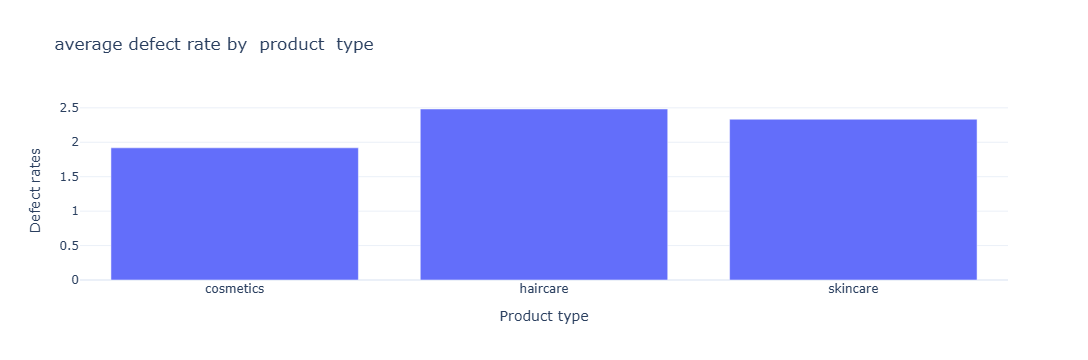

In [29]:
a = df.groupby('Product type')['Defect rates'].mean().reset_index()
b = px.bar(a,x='Product type',
      y='Defect rates',
      title = 'average defect rate by  product  type')
b.show()

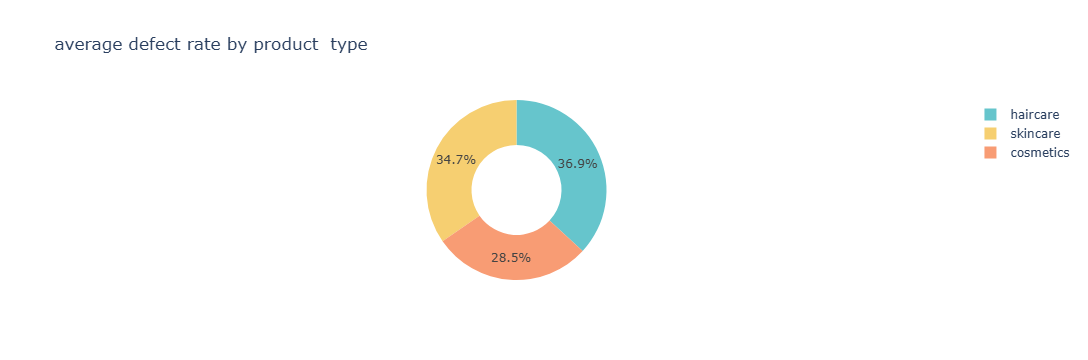

In [31]:
aa = df.groupby('Product type')['Defect rates'].mean().reset_index()

bb = px.pie(aa,names ='Product type',
      values='Defect rates',
      title ='average defect rate by product  type',
      hole  = 0.5,
      color_discrete_sequence=px.colors.qualitative.Pastel)
bb.show()

# So the defect rate of haircare products is higher.Now let’s have a look at the defect rates by mode of transportation:

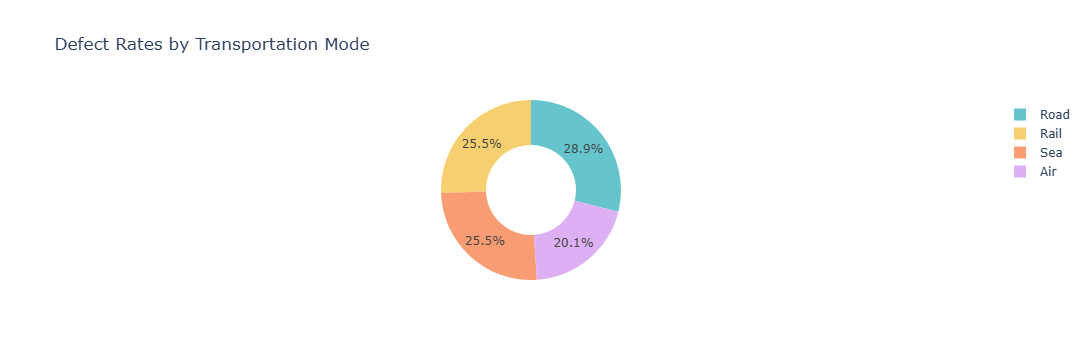

In [33]:
pivot_table = pd.pivot_table(df, values='Defect rates',
index=['Transportation modes'],
aggfunc='mean')

transportation_chart = px.pie(values=pivot_table["Defect rates"],
names=pivot_table.index,
title='Defect Rates by Transportation Mode',
hole=0.5,
color_discrete_sequence=
px.colors.qualitative.Pastel)

transportation_chart.show()